# Chinese dynasties
Counts individuals per Chinese dynasty (Shang → Qing) and the temporal precision of their dates.

In [1]:
import random
import tempfile

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import PercentFormatter
from style import *

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_enriched_v3.duckdb'

apply_style()

## External data — none

## Chinese dynasty list

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

con.sql('''
    CREATE TEMP TABLE chinese_territories AS
    SELECT name                 AS name,
           territory.start_year AS start_year,
           territory.end_year   AS end_year
    FROM   polity, unnest(territories) AS unnested(territory)
    WHERE  list_contains(world, 'Chinese world')
''')

CHINESE_DYNASTIES = con.sql('''
    SELECT   name, MIN(start_year) AS first_year
    FROM     chinese_territories
    GROUP BY name
    ORDER BY first_year, name
''').pl()['name'].to_list()
assert len(set(CHINESE_DYNASTIES)) == len(CHINESE_DYNASTIES)
print(f'Chinese-world polities: {len(CHINESE_DYNASTIES)}')
print(CHINESE_DYNASTIES)

Chinese-world polities: 24
['Shang Dynasty', 'Zhou Dynasty', 'Qin Dynasty', 'Han Dynasty', 'Xin Dynasty', 'Western Jin', 'Northern Wei', 'Liu Song Dynasty', 'Liang Dynasty', 'Eastern Wei', 'Western Wei', 'Northern Qi', 'Chen Dynasty', 'Northern Zhou', 'Sui Dynasty', 'Tang Dynasty', 'Five Dynasties and Ten Kingdoms', 'Liao Dynasty', 'Northern Song', 'Western Xia', 'Southern Song', 'Yuan Dynasty', 'Ming Dynasty', 'Qing Dynasty']


## Load data
### Dynasty periods

In [3]:
dynasty_periods = con.sql("""
    SELECT   name            AS dynasty,
             MIN(start_year) AS from_year,
             MAX(end_year)   AS to_year
    FROM     chinese_territories
    GROUP BY name
""").pl()

assert dynasty_periods['dynasty'].is_unique
print('shape:', dynasty_periods.shape)
dynasty_periods.sort('from_year').head()

shape: (24, 3)


dynasty,from_year,to_year
str,i64,i64
"""Shang Dynasty""",-1600,-1001
"""Zhou Dynasty""",-1000,-751
"""Qin Dynasty""",-218,-209
"""Han Dynasty""",-202,237
"""Xin Dynasty""",6,29


### Individuals per dynasty

In [4]:
con.sql("""
    CREATE TEMP TABLE dynasty_matches AS
    SELECT entity.qid                           AS qid,
           match.polity.name                    AS dynasty,
           peak_productivity.start_year         AS peak_start,
           peak_productivity.end_year           AS peak_end,
           peak_productivity.assignation_method AS peak_method
    FROM   (SELECT entity, peak_productivity, unnest(polity) AS match FROM individual_enriched)
    WHERE  list_contains($names, match.polity.name)
""", params={'names': CHINESE_DYNASTIES})

dynasty_individuals = con.sql("""
    SELECT dynasty_matches.*,
           list_filter(individual.birth_date, d -> d.precision IN ('day', 'month', 'year', 'decade'))[1].precision   AS birth_precision,
           list_filter(individual.death_date, d -> d.precision IN ('day', 'month', 'year', 'decade'))[1].precision   AS death_precision,
           list_filter(individual.floruit_date, d -> d.precision IN ('day', 'month', 'year', 'decade'))[1].precision AS floruit_precision
    FROM   dynasty_matches
    JOIN   individual ON individual.entity.qid = dynasty_matches.qid
""").pl()

con.close()

assert dynasty_individuals.select('qid', 'dynasty').is_duplicated().sum() == 0
print('shape:', dynasty_individuals.shape)
print('distinct individuals:', dynasty_individuals['qid'].n_unique())
dynasty_individuals.head()

shape: (89990, 8)
distinct individuals: 88845


qid,dynasty,peak_start,peak_end,peak_method,birth_precision,death_precision,floruit_precision
str,str,i64,i64,str,str,str,str
"""Q11039424""","""Ming Dynasty""",1630,1630,"""birth_death_wikidata_property""","""year""","""year""",null
"""Q12624306""","""Yuan Dynasty""",1313,1335,"""birth_death_wikidata_property""","""year""","""year""",null
"""Q12624988""","""Tang Dynasty""",501,700,"""birth_only_century_wikidata_pr…",null,null,null
"""Q131323642""","""Qing Dynasty""",1825,1849,"""birth_death_wikidata_property""","""year""","""year""",null
"""Q11576779""","""Qing Dynasty""",1896,1920,"""birth_death_wikidata_property""","""year""","""year""",null


## Preprocessing
### Counts per dynasty

In [5]:
dynasty_counts = (
    dynasty_individuals
    .group_by('dynasty')
    .agg(
        pl.len().alias('all_individuals'),
        pl.col('peak_method').is_not_null().sum().alias('with_peak_window'),
    )
)

dynasty_summary = (
    pl.DataFrame({'dynasty': CHINESE_DYNASTIES})
    .join(dynasty_periods, on='dynasty', how='left')
    .join(dynasty_counts, on='dynasty', how='left')
    .with_columns(pl.col('all_individuals', 'with_peak_window').fill_null(0))
    .with_columns(
        (pl.col('all_individuals') - pl.col('with_peak_window')).alias('missing_peak_window'),
        (100 * pl.col('with_peak_window') / pl.col('all_individuals')).round(1).alias('pct_with_peak_window'),
    )
)

assert dynasty_summary['all_individuals'].sum() == dynasty_individuals.height
assert dynasty_summary['missing_peak_window'].sum() == 0
print('shape:', dynasty_summary.shape)
dynasty_summary.head(len(CHINESE_DYNASTIES))

shape: (24, 7)


dynasty,from_year,to_year,all_individuals,with_peak_window,missing_peak_window,pct_with_peak_window
str,i64,i64,u32,u32,u32,f64
"""Shang Dynasty""",-1600,-1001,9,9,0,100.0
"""Zhou Dynasty""",-1000,-751,26,26,0,100.0
"""Qin Dynasty""",-218,-209,94,94,0,100.0
"""Han Dynasty""",-202,237,1068,1068,0,100.0
"""Xin Dynasty""",6,29,110,110,0,100.0
…,…,…,…,…,…,…
"""Western Xia""",990,1226,18,18,0,100.0
"""Southern Song""",1028,1278,6348,6348,0,100.0
"""Yuan Dynasty""",1294,1374,3088,3088,0,100.0


### Temporal precision

In [6]:
PRECISION_BUCKET = {'day': 'year', 'month': 'year', 'year': 'year', 'decade': 'decade',
                    'century': 'century', 'millennium': 'century'}
PRECISION_COLUMNS = ['year', 'decade', 'century']

source_precision = (
    pl.when(pl.col('peak_method').str.contains('century')).then(pl.lit('century'))
      .when(pl.col('peak_method').str.starts_with('floruit')).then(pl.col('floruit_precision'))
      .when(pl.col('peak_method').str.starts_with('birth') | pl.col('peak_method').str.starts_with('died_young')).then(pl.col('birth_precision'))
      .when(pl.col('peak_method').str.starts_with('death_only')).then(pl.col('death_precision'))
      .when(pl.col('peak_method').str.starts_with('works')).then(pl.lit('year'))
)

dynasty_precision = dynasty_individuals.with_columns(
    source_precision.replace_strict(PRECISION_BUCKET, default=None).alias('precision')
)
assert dynasty_precision['precision'].null_count() == 0
print(dynasty_precision.group_by('peak_method', 'precision').len().sort('len', descending=True).head(15))

precision_counts = (
    pl.DataFrame({'dynasty': CHINESE_DYNASTIES})
    .join(dynasty_precision.pivot(on='precision', index='dynasty', values='qid', aggregate_function='len'),
          on='dynasty', how='left')
)
for column in PRECISION_COLUMNS:
    if column not in precision_counts.columns:
        precision_counts = precision_counts.with_columns(pl.lit(0).alias(column))
precision_counts = (
    precision_counts
    .with_columns(pl.col(PRECISION_COLUMNS).fill_null(0).cast(pl.Int64))
    .with_columns(pl.sum_horizontal(PRECISION_COLUMNS).alias('total'))
    .select('dynasty', *PRECISION_COLUMNS, 'total')
)

assert precision_counts['total'].sum() == dynasty_individuals.height
print('shape:', precision_counts.shape)
precision_counts.head(len(CHINESE_DYNASTIES))

shape: (15, 3)
┌─────────────────────────────────┬───────────┬───────┐
│ peak_method                     ┆ precision ┆ len   │
│ ---                             ┆ ---       ┆ ---   │
│ str                             ┆ str       ┆ u32   │
╞═════════════════════════════════╪═══════════╪═══════╡
│ birth_death_wikidata_property   ┆ year      ┆ 34796 │
│ death_only_wikidata_property    ┆ year      ┆ 29664 │
│ birth_only_wikidata_property    ┆ year      ┆ 23460 │
│ birth_only_century_wikidata_pr… ┆ century   ┆ 1085  │
│ died_young_wikidata_property    ┆ year      ┆ 381   │
│ …                               ┆ …         ┆ …     │
│ works_span                      ┆ year      ┆ 25    │
│ death_only_wikidata_property    ┆ decade    ┆ 24    │
│ death_only_century_wikidata_pr… ┆ century   ┆ 17    │
│ floruit_wikidata_property       ┆ decade    ┆ 10    │
│ died_young_wikidata_property    ┆ decade    ┆ 5     │
└─────────────────────────────────┴───────────┴───────┘
shape: (24, 5)


dynasty,year,decade,century,total
str,i64,i64,i64,i64
"""Shang Dynasty""",7,0,2,9
"""Zhou Dynasty""",18,0,8,26
"""Qin Dynasty""",65,4,25,94
"""Han Dynasty""",787,28,253,1068
"""Xin Dynasty""",46,0,64,110
…,…,…,…,…
"""Western Xia""",18,0,0,18
"""Southern Song""",6277,8,63,6348
"""Yuan Dynasty""",3001,6,81,3088


## Figures
### Temporal precision per dynasty

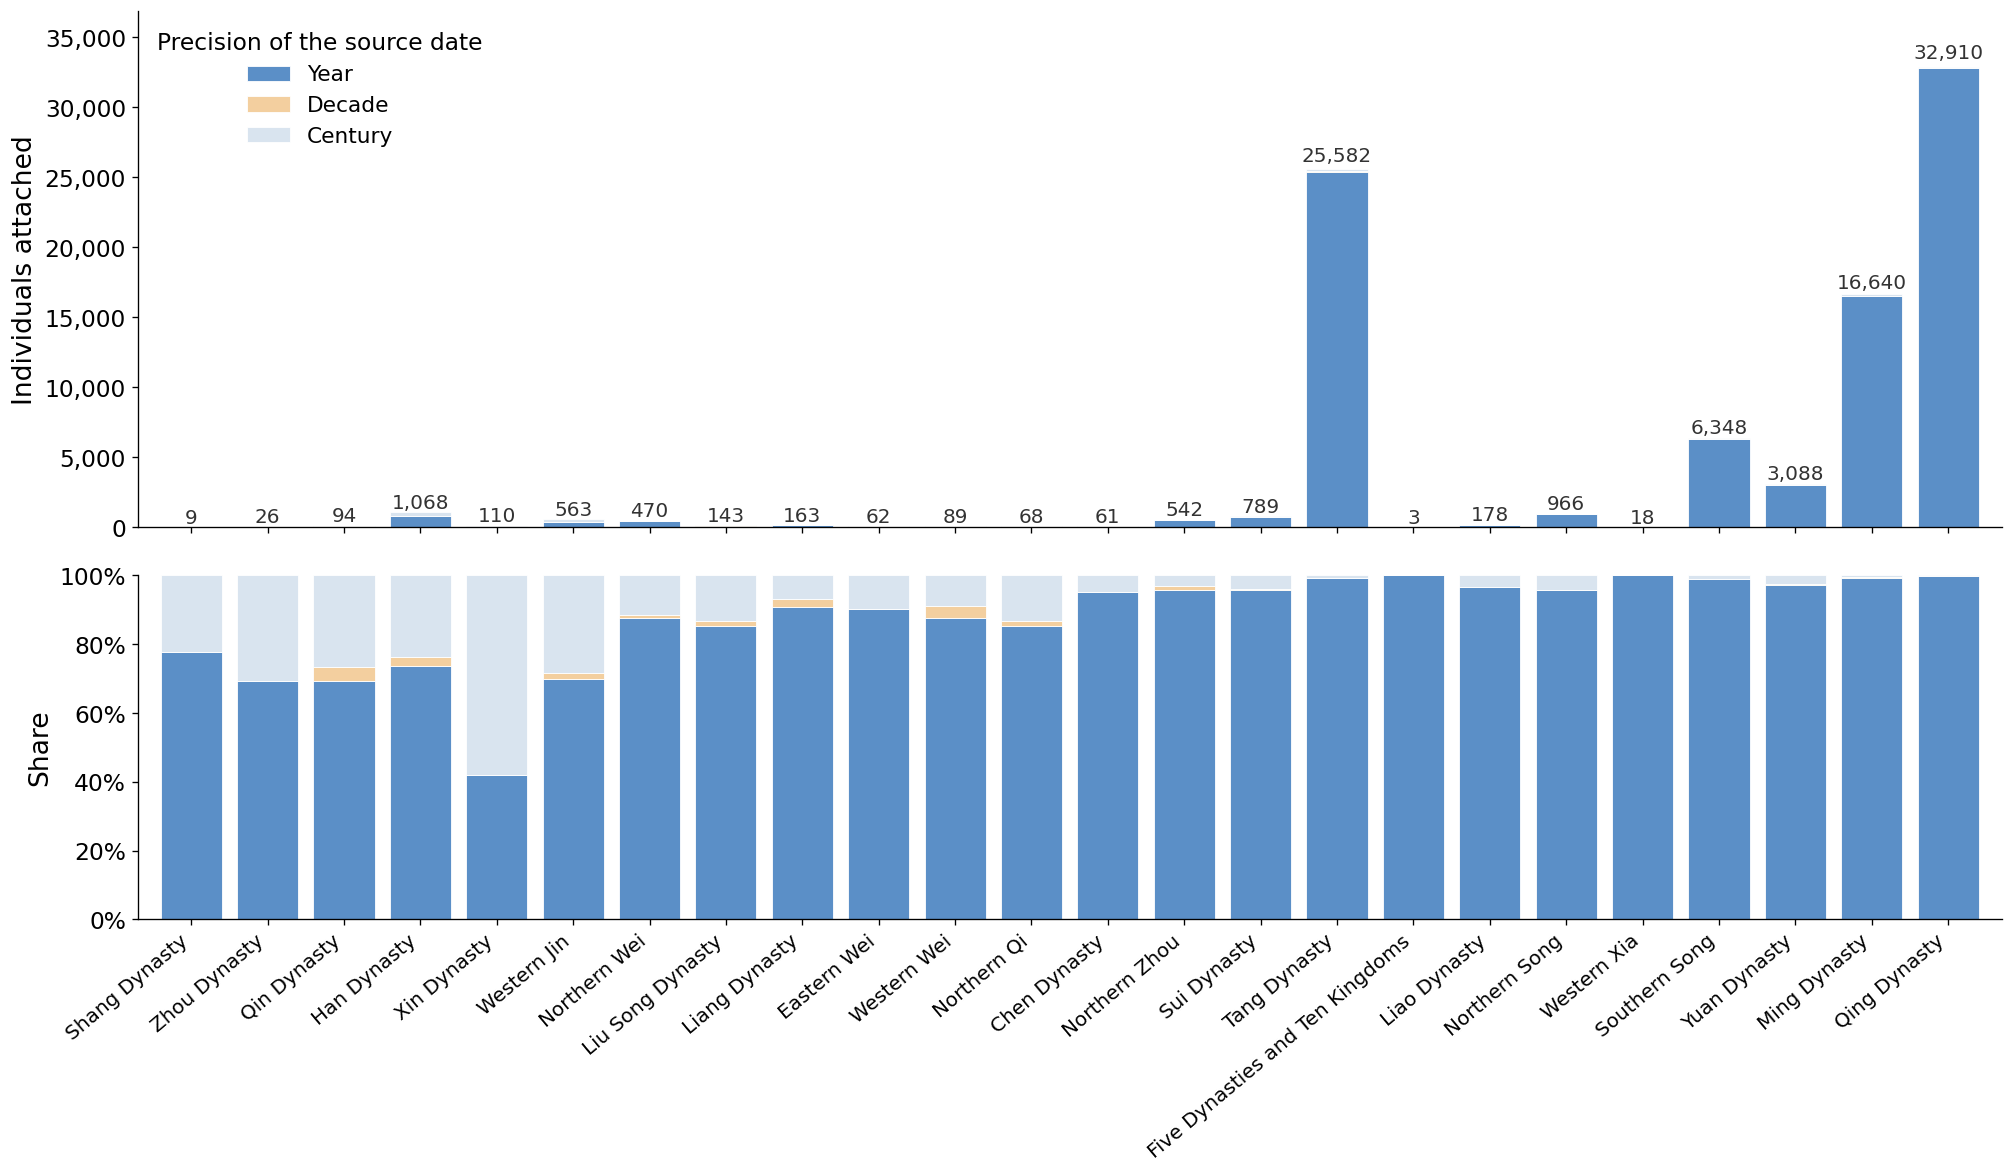

In [7]:
PRECISION_LABELS = {'year': 'Year', 'decade': 'Decade', 'century': 'Century'}

dynasty_axis = precision_counts['dynasty'].to_list()
totals = precision_counts['total'].to_numpy().astype(float)
xs = np.arange(len(dynasty_axis))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(17, 10), sharex=True, gridspec_kw={'height_ratios': [3, 2]})

bottoms = np.zeros(len(xs))
for column in PRECISION_COLUMNS:
    counts = precision_counts[column].to_numpy().astype(float)
    ax_top.bar(xs, counts, bottom=bottoms, color=PRECISION_COLORS[column], edgecolor=BACKGROUND_COLOR,
               linewidth=0.5, label=PRECISION_LABELS[column])
    bottoms += counts
for x, total in zip(xs, totals):
    if total > 0:
        ax_top.text(x, total * 1.01, f'{int(total):,}', ha='center', va='bottom', fontsize=VALUE_LABEL_FONTSIZE, color=TEXT)
ax_top.set_ylim(0, totals.max() * 1.12)
ax_top.yaxis.set_major_formatter(THOUSANDS)
ax_top.set_ylabel('Individuals attached')
ax_top.legend(loc='upper left', title='Precision of the source date')

shares = precision_counts.select(PRECISION_COLUMNS).to_numpy() / np.where(totals == 0, np.nan, totals)[:, None]
shares = np.nan_to_num(shares)
bottoms = np.zeros(len(xs))
for j, column in enumerate(PRECISION_COLUMNS):
    ax_bot.bar(xs, shares[:, j], bottom=bottoms, color=PRECISION_COLORS[column], edgecolor=BACKGROUND_COLOR, linewidth=0.5)
    bottoms += shares[:, j]
ax_bot.set_xticks(xs)
ax_bot.set_xticklabels(dynasty_axis, rotation=40, ha='right', fontsize=LONG_TICK_LABEL_FONTSIZE)
ax_bot.set_xlim(-0.7, len(xs) - 0.3)
ax_bot.set_ylim(0, 1)
ax_bot.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax_bot.set_ylabel('Share')

fig.tight_layout()
plt.show()